# **I-80 Road Closure Risk Ranking Model**

This notebook trains a dashboard-ready model that ranks the risk of I-80 being closed at any point within the next 24 hours. The model produces a continuous probability and maps it into four operational categories: **Low, Medium, High, and Extreme**.

The categories are score bands, not separately observed outcomes. Historical closure outcomes train the binary probability model; validation data determine category boundaries.

## Setup

In [3]:
from pathlib import Path
import json
import sys

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score, brier_score_loss, precision_recall_curve,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

SEED = 42
np.random.seed(SEED)

PROJECT_ROOT = next(
    (p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
     if (p / 'main' / 'data' / 'weather_closure_forecast_targets.csv').exists()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Could not locate the road_project root.')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from main.risk_model import assign_risk_category, score_feature_frame

DATA_PATH = PROJECT_ROOT / 'main' / 'data' / 'weather_closure_forecast_targets.csv'
OUTPUT_DIR = PROJECT_ROOT / 'main' / 'outputs' / 'modeling'
ARTIFACT_PATH = OUTPUT_DIR / 'i80_24h_risk_model.joblib'
METADATA_PATH = OUTPUT_DIR / 'i80_24h_risk_model_metadata.json'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def finish_plot(filename):
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=300, bbox_inches='tight')
    plt.show()

## Outcome and temporal split

The model uses `road_closed_within_24h` because the intended product is a daily road-status risk ranking. Twenty-four hours also has more positive examples than the shorter horizons.

- **Training:** 2016–2017 through 2022–2023
- **Validation:** 2023–2024, used for model and category-boundary selection
- **Final test:** 2024–2025, evaluated once after every choice is frozen
- **Excluded:** incomplete 2025–2026 winter

In [4]:
df = pd.read_csv(DATA_PATH, parse_dates=['date'])
assert df['date'].is_monotonic_increasing and df['date'].is_unique
assert df.isna().sum().sum() == 0

TARGET = 'road_closed_within_24h'
HORIZON_HOURS = 24
TRAIN_WINTERS = [
    '2016-2017', '2017-2018', '2018-2019', '2019-2020',
    '2020-2021', '2021-2022', '2022-2023',
]
VALIDATION_WINTER = '2023-2024'
TEST_WINTER = '2024-2025'
EXCLUDED_WINTER = '2025-2026'

split_summary = df.groupby('winter').agg(
    rows=('date', 'size'),
    closure_starts=('closure_start', 'sum'),
    positive_24h=(TARGET, 'sum'),
)
display(split_summary)

,rows,closure_starts,positive_24h
winter,,,
2016-2017,2177,16,236
2017-2018,5378,26,453
2018-2019,5173,47,594
2019-2020,5531,23,261
2020-2021,5622,14,214
2021-2022,5358,26,498
2022-2023,5316,47,629
2023-2024,5704,10,168
2024-2025,5500,17,313


## Features and leakage controls

Features are limited to signals justified by the EDA and available when a score is issued:

- snowfall and precipitation measure active storm intensity;
- surface pressure and its six-hour change describe storm development;
- low/mid cloud cover and WMO weather code represent poor conditions;
- wind, temperature, humidity, and snow depth represent blowing snow, freezing, and accumulated hazard;
- six- and 24-hour trailing summaries capture storm accumulation;
- cyclical local month/hour terms represent season and operations without treating December and January as far apart.

Outcome columns, current closure status, closure starts, winter labels, raw dates, and year are excluded. Trailing features require consecutive hourly records, so observations after an ambiguous-data gap are removed until a complete history is available.

In [5]:
BASE_NUMERIC_FEATURES = [
    'snowfall', 'precipitation', 'surface_pressure', 'cloud_cover_low',
    'cloud_cover_mid', 'wind_speed_100m', 'temperature_2m', 'snow_depth',
    'relative_humidity_2m',
]
CATEGORICAL_FEATURES = ['weather_code']

def add_model_features(frame):
    out = frame.copy().sort_values('date')
    local_date = out['date'].dt.tz_convert('America/Los_Angeles')
    out['month_sin'] = np.sin(2 * np.pi * local_date.dt.month / 12)
    out['month_cos'] = np.cos(2 * np.pi * local_date.dt.month / 12)
    out['hour_sin'] = np.sin(2 * np.pi * local_date.dt.hour / 24)
    out['hour_cos'] = np.cos(2 * np.pi * local_date.dt.hour / 24)

    groups = out.groupby('winter', sort=False)
    for hours in (6, 24):
        rolling_specs = {
            f'snowfall_sum_{hours}h': ('snowfall', 'sum'),
            f'precipitation_sum_{hours}h': ('precipitation', 'sum'),
            f'wind_mean_{hours}h': ('wind_speed_100m', 'mean'),
            f'temperature_min_{hours}h': ('temperature_2m', 'min'),
        }
        for output_column, (source_column, operation) in rolling_specs.items():
            out[output_column] = groups[source_column].transform(
                lambda values: getattr(values.rolling(hours, min_periods=hours), operation)()
            )
        history_start = groups['date'].shift(hours - 1)
        complete_history = out['date'].sub(history_start).eq(pd.Timedelta(hours=hours - 1))
        for output_column in rolling_specs:
            out.loc[~complete_history, output_column] = np.nan

    pressure_lag = groups['surface_pressure'].shift(6)
    pressure_time = groups['date'].shift(6)
    out['pressure_change_6h'] = out['surface_pressure'] - pressure_lag
    out.loc[~out['date'].sub(pressure_time).eq(pd.Timedelta(hours=6)), 'pressure_change_6h'] = np.nan
    return out

model_df = add_model_features(df)
ENGINEERED_FEATURES = [
    'month_sin', 'month_cos', 'hour_sin', 'hour_cos',
    'snowfall_sum_6h', 'snowfall_sum_24h',
    'precipitation_sum_6h', 'precipitation_sum_24h',
    'wind_mean_6h', 'wind_mean_24h',
    'temperature_min_6h', 'temperature_min_24h', 'pressure_change_6h',
]
NUMERIC_FEATURES = BASE_NUMERIC_FEATURES + ENGINEERED_FEATURES
MODEL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
model_df = model_df.dropna(subset=MODEL_FEATURES).reset_index(drop=True)

LEAKAGE_COLUMNS = {'closure', 'closure_start', 'road_closed_within_6h', 'road_closed_within_12h', 'road_closed_within_24h'}
assert not LEAKAGE_COLUMNS.intersection(MODEL_FEATURES)
print(f'Modeling rows: {len(model_df):,}; features: {len(MODEL_FEATURES)}')

Modeling rows: 45,800; features: 23


In [6]:
train_df = model_df[model_df['winter'].isin(TRAIN_WINTERS)].copy()
validation_df = model_df[model_df['winter'].eq(VALIDATION_WINTER)].copy()
test_df = model_df[model_df['winter'].eq(TEST_WINTER)].copy()
assert train_df['date'].max() < validation_df['date'].min() < test_df['date'].min()

X_train, y_train = train_df[MODEL_FEATURES], train_df[TARGET].astype(int)
X_validation, y_validation = validation_df[MODEL_FEATURES], validation_df[TARGET].astype(int)
X_test, y_test = test_df[MODEL_FEATURES], test_df[TARGET].astype(int)

print('Train:', len(train_df), 'positive rate:', round(y_train.mean(), 4))
print('Validation:', len(validation_df), 'positive rate:', round(y_validation.mean(), 4))
print('Test locked:', len(test_df), 'positive rate:', round(y_test.mean(), 4))

Train: 31568 positive rate: 0.0758
Validation: 5509 positive rate: 0.0267
Test locked: 5168 positive rate: 0.0563


## Preprocessing and model candidates

Numeric variables are median-imputed and standardized from training data only. Weather code is one-hot encoded because its values are categories rather than a continuous severity scale.

Hyperparameter grids are intentionally small to limit validation overfitting. Logistic regression is the interpretable baseline, random forest captures interactions, and histogram gradient boosting captures smooth nonlinear risk patterns efficiently.

In [7]:
def make_preprocessor():
    return ColumnTransformer([
        ('numeric', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scale', StandardScaler()),
        ]), NUMERIC_FEATURES),
        ('categorical', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('one_hot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
        ]), CATEGORICAL_FEATURES),
    ], verbose_feature_names_out=False)

MODEL_CANDIDATES = {
    'Logistic regression': [
        LogisticRegression(C=0.1, max_iter=2000, random_state=SEED),
        LogisticRegression(C=1.0, max_iter=2000, random_state=SEED),
    ],
    'Random forest': [
        RandomForestClassifier(n_estimators=75, max_depth=6, min_samples_leaf=50, max_features='sqrt', random_state=SEED, n_jobs=1),
        RandomForestClassifier(n_estimators=75, max_depth=8, min_samples_leaf=100, max_features=0.7, random_state=SEED, n_jobs=1),
    ],
    'Histogram gradient boosting': [
        HistGradientBoostingClassifier(max_iter=120, learning_rate=0.05, max_leaf_nodes=15, min_samples_leaf=50, l2_regularization=1.0, early_stopping=False, random_state=SEED),
        HistGradientBoostingClassifier(max_iter=100, learning_rate=0.08, max_leaf_nodes=15, min_samples_leaf=100, l2_regularization=2.0, early_stopping=False, random_state=SEED),
    ],
}

def probability_metrics(y_true, probabilities):
    return {
        'average_precision': average_precision_score(y_true, probabilities),
        'roc_auc': roc_auc_score(y_true, probabilities),
        'brier_score': brier_score_loss(y_true, probabilities),
    }

## Train and select the probability model on validation data

Average precision is the primary selection metric because closures are rare. Brier score is retained to assess probability calibration. No test results are used here.

In [8]:
validation_rows = []
best_by_family = {}

for family, estimators in MODEL_CANDIDATES.items():
    family_best = None
    family_best_ap = -np.inf
    for candidate_number, estimator in enumerate(estimators, start=1):
        pipeline = Pipeline([('preprocess', make_preprocessor()), ('model', estimator)])
        pipeline.fit(X_train, y_train)
        validation_probability = pipeline.predict_proba(X_validation)[:, 1]
        metrics = probability_metrics(y_validation, validation_probability)
        validation_rows.append({
            'model_family': family, 'candidate': candidate_number, **metrics,
            'parameters': str(estimator.get_params()),
        })
        if metrics['average_precision'] > family_best_ap:
            family_best_ap = metrics['average_precision']
            family_best = (pipeline, validation_probability, candidate_number)
    best_by_family[family] = family_best

validation_results = pd.DataFrame(validation_rows).sort_values('average_precision', ascending=False)
display(validation_results[['model_family', 'candidate', 'average_precision', 'roc_auc', 'brier_score']].round(4))
validation_results.to_csv(OUTPUT_DIR / 'risk_model_validation_results.csv', index=False)

best_row = validation_results.iloc[0]
SELECTED_FAMILY = best_row['model_family']
selected_pipeline, validation_probability, selected_candidate = best_by_family[SELECTED_FAMILY]
training_probability = selected_pipeline.predict_proba(X_train)[:, 1]
print('Selected:', SELECTED_FAMILY, 'candidate', selected_candidate)

,model_family,candidate,average_precision,roc_auc,brier_score
3,Random forest,2,0.0894,0.7031,0.0313
2,Random forest,1,0.0866,0.6677,0.0316
0,Logistic regression,1,0.0586,0.7232,0.0332
1,Logistic regression,2,0.0584,0.7239,0.0333
4,Histogram gradient boosting,1,0.0515,0.6189,0.0319
5,Histogram gradient boosting,2,0.0473,0.6427,0.0338


Selected: Random forest candidate 2


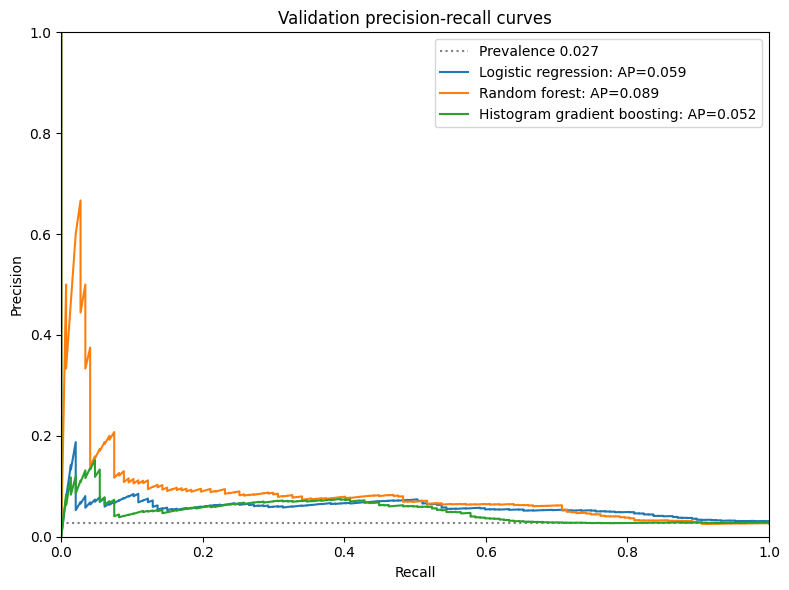

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.axhline(y_validation.mean(), color='gray', linestyle=':', label=f'Prevalence {y_validation.mean():.3f}')
for family, (_, probabilities, _) in best_by_family.items():
    precision, recall, _ = precision_recall_curve(y_validation, probabilities)
    ap = average_precision_score(y_validation, probabilities)
    ax.plot(recall, precision, label=f'{family}: AP={ap:.3f}')
ax.set(title='Validation precision-recall curves', xlabel='Recall', ylabel='Precision', xlim=(0, 1), ylim=(0, 1))
ax.legend()
finish_plot('01_risk_model_validation_precision_recall.png')

## Tune Low / Medium / High / Extreme boundaries

There is no observed four-class target, so boundaries should not pretend to be natural labels. Candidate boundaries are training-score percentiles:

- Low/Medium candidates: 50th, 60th, or 70th percentile
- Medium/High candidates: 80th, 85th, or 90th percentile
- High/Extreme candidates: 95th, 97th, or 98th percentile

Validation selects the set whose four-level ranking has the highest average precision. Configurations with non-monotonic observed closure rates or categories containing under 0.5% of validation hours are penalized. This balances discrimination with dashboard usability.

In [10]:
RISK_LEVEL = {'Low': 0, 'Medium': 1, 'High': 2, 'Extreme': 3}

def category_summary(y_true, categories):
    table = pd.DataFrame({'outcome': np.asarray(y_true), 'risk_category': categories})
    summary = table.groupby('risk_category', observed=False).agg(
        hours=('outcome', 'size'),
        closures=('outcome', 'sum'),
        observed_closure_rate=('outcome', 'mean'),
    ).reindex(['Low', 'Medium', 'High', 'Extreme'])
    summary['share_of_hours'] = summary['hours'] / summary['hours'].sum()
    summary['share_of_positive_hours'] = summary['closures'] / max(summary['closures'].sum(), 1)
    summary['lift_vs_baseline'] = summary['observed_closure_rate'] / table['outcome'].mean()
    return summary

threshold_rows = []
for low_quantile in (0.50, 0.60, 0.70):
    for high_quantile in (0.80, 0.85, 0.90):
        for extreme_quantile in (0.95, 0.97, 0.98):
            quantiles = [low_quantile, high_quantile, extreme_quantile]
            cutoffs = np.quantile(training_probability, quantiles)
            if not np.all(np.diff(cutoffs) > 0):
                continue
            thresholds = dict(zip(['low_medium', 'medium_high', 'high_extreme'], cutoffs))
            categories = assign_risk_category(validation_probability, thresholds)
            levels = np.array([RISK_LEVEL[value] for value in categories])
            summary = category_summary(y_validation, categories)
            rates = summary['observed_closure_rate'].fillna(0).to_numpy()
            monotonic_violations = int((np.diff(rates) < 0).sum())
            tiny_categories = int((summary['share_of_hours'].fillna(0) < 0.005).sum())
            binned_ap = average_precision_score(y_validation, levels)
            objective = binned_ap - 0.05 * monotonic_violations - 0.05 * tiny_categories
            threshold_rows.append({
                'low_quantile': low_quantile, 'high_quantile': high_quantile,
                'extreme_quantile': extreme_quantile, **thresholds,
                'binned_average_precision': binned_ap,
                'monotonic_violations': monotonic_violations,
                'tiny_categories': tiny_categories, 'objective': objective,
            })

threshold_search = pd.DataFrame(threshold_rows).sort_values('objective', ascending=False)
best_threshold_row = threshold_search.iloc[0]
CATEGORY_THRESHOLDS = {
    key: float(best_threshold_row[key])
    for key in ['low_medium', 'medium_high', 'high_extreme']
}
validation_categories = assign_risk_category(validation_probability, CATEGORY_THRESHOLDS)
validation_category_summary = category_summary(y_validation, validation_categories)
display(threshold_search.head(10).round(4))
display(validation_category_summary.round(4))
threshold_search.to_csv(OUTPUT_DIR / 'risk_category_threshold_search.csv', index=False)
validation_category_summary.to_csv(OUTPUT_DIR / 'risk_category_validation_summary.csv')

,low_quantile,high_quantile,extreme_quantile,low_medium,medium_high,high_extreme,binned_average_precision,monotonic_violations,tiny_categories,objective
23,0.7,0.85,0.98,0.0570,0.0931,0.4024,0.0653,0,0,0.0653
26,0.7,0.90,0.98,0.0570,0.1480,0.4024,0.0634,0,0,0.0634
14,0.6,0.85,0.98,0.0514,0.0931,0.4024,0.0632,0,0,0.0632
22,0.7,0.85,0.97,0.0570,0.0931,0.3407,0.0626,0,0,0.0626
5,0.5,0.85,0.98,0.0479,0.0931,0.4024,0.0625,0,0,0.0625
21,0.7,0.85,0.95,0.0570,0.0931,0.2640,0.0614,0,0,0.0614
25,0.7,0.90,0.97,0.0570,0.1480,0.3407,0.0606,0,0,0.0606
13,0.6,0.85,0.97,0.0514,0.0931,0.3407,0.0606,0,0,0.0606
20,0.7,0.80,0.98,0.0570,0.0703,0.4024,0.0604,0,0,0.0604
4,0.5,0.85,0.97,0.0479,0.0931,0.3407,0.0599,0,0,0.0599


,hours,closures,observed_closure_rate,share_of_hours,share_of_positive_hours,lift_vs_baseline
risk_category,,,,,,
Low,3845,44,0.0114,0.6979,0.2993,0.4289
Medium,744,32,0.0430,0.1351,0.2177,1.6119
High,871,62,0.0712,0.1581,0.4218,2.6677
Extreme,49,9,0.1837,0.0089,0.0612,6.8834


## Final test — run once

The selected model and category cutoffs are now frozen. This is the only evaluation on the 2024–2025 test winter.

In [11]:
test_probability = selected_pipeline.predict_proba(X_test)[:, 1]
test_categories = assign_risk_category(test_probability, CATEGORY_THRESHOLDS)
test_probability_metrics = probability_metrics(y_test, test_probability)
test_category_summary = category_summary(y_test, test_categories)

test_metrics = pd.DataFrame([{
    'model_family': SELECTED_FAMILY, 'target': TARGET, 'test_winter': TEST_WINTER,
    **test_probability_metrics, 'test_prevalence': y_test.mean(),
}])
display(test_metrics.round(4))
display(test_category_summary.round(4))
test_metrics.to_csv(OUTPUT_DIR / 'risk_model_final_test_metrics.csv', index=False)
test_category_summary.to_csv(OUTPUT_DIR / 'risk_category_final_test_summary.csv')

test_scored = test_df[['date', 'winter', TARGET]].copy()
test_scored['closure_risk_score'] = test_probability
test_scored['closure_risk_category'] = test_categories
test_scored.to_csv(OUTPUT_DIR / 'risk_model_test_predictions.csv', index=False)

,model_family,target,test_winter,average_precision,roc_auc,brier_score,test_prevalence
0,Random forest,will_close_in_24h,2024-2025,0.2529,0.807,0.0478,0.0563


,hours,closures,observed_closure_rate,share_of_hours,share_of_positive_hours,lift_vs_baseline
risk_category,,,,,,
Low,3600,68,0.0189,0.6966,0.2337,0.3355
Medium,672,49,0.0729,0.1300,0.1684,1.2950
High,828,136,0.1643,0.1602,0.4674,2.9170
Extreme,68,38,0.5588,0.0132,0.1306,9.9244


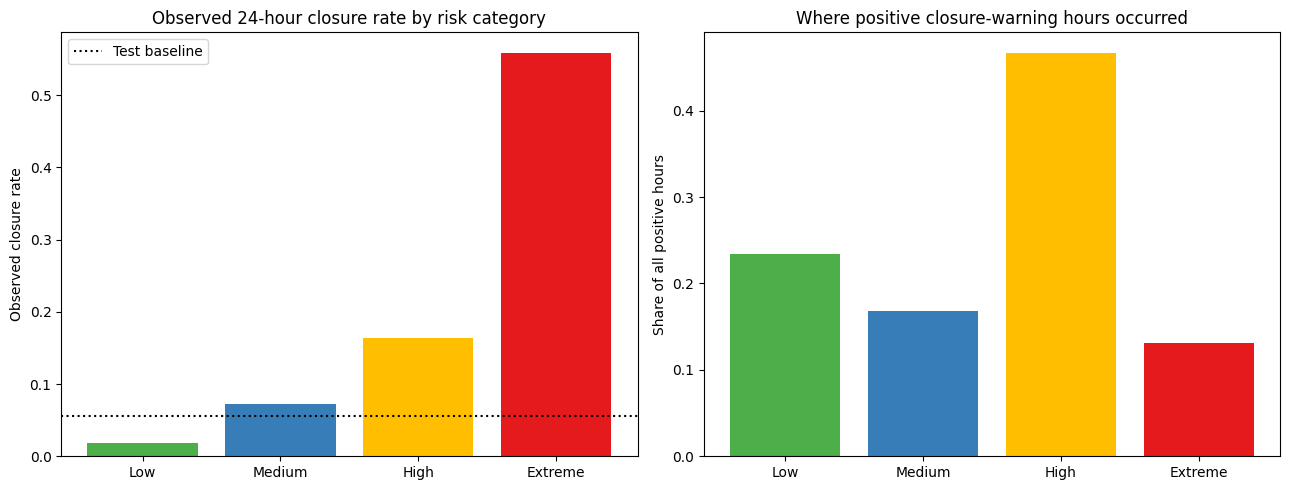

In [12]:
plot_summary = test_category_summary.reset_index()
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(plot_summary['risk_category'], plot_summary['observed_closure_rate'], color=['#4daf4a', '#377eb8', '#ffbf00', '#e41a1c'])
axes[0].axhline(y_test.mean(), color='black', linestyle=':', label='Test baseline')
axes[0].set(title='Observed 24-hour closure rate by risk category', ylabel='Observed closure rate', xlabel='')
axes[0].legend()
axes[1].bar(plot_summary['risk_category'], plot_summary['share_of_positive_hours'], color=['#4daf4a', '#377eb8', '#ffbf00', '#e41a1c'])
axes[1].set(title='Where positive closure-warning hours occurred', ylabel='Share of all positive hours', xlabel='')
finish_plot('02_risk_category_final_test.png')

## Save the reusable model artifact

The artifact contains the fitted preprocessing pipeline and classifier, frozen probability cutoffs, feature order, horizon, split metadata, and held-out metrics. `main/risk_model.py` provides reusable loading and scoring functions. Daily scoring must construct the same current and trailing weather features before calling the artifact.

In [13]:
metadata = {
    'artifact_version': 1,
    'model_family': SELECTED_FAMILY,
    'selected_candidate': int(selected_candidate),
    'target': TARGET,
    'horizon_hours': HORIZON_HOURS,
    'risk_labels': ['Low', 'Medium', 'High', 'Extreme'],
    'model_features': MODEL_FEATURES,
    'numeric_features': NUMERIC_FEATURES,
    'categorical_features': CATEGORICAL_FEATURES,
    'train_winters': TRAIN_WINTERS,
    'validation_winter': VALIDATION_WINTER,
    'test_winter': TEST_WINTER,
    'excluded_incomplete_winter': EXCLUDED_WINTER,
    'threshold_training_quantiles': {
        'low_medium': float(best_threshold_row['low_quantile']),
        'medium_high': float(best_threshold_row['high_quantile']),
        'high_extreme': float(best_threshold_row['extreme_quantile']),
    },
    'test_metrics': {key: float(value) for key, value in test_probability_metrics.items()},
    'feature_history_requirement_hours': 24,
}
artifact = {
    'pipeline': selected_pipeline,
    'category_thresholds': CATEGORY_THRESHOLDS,
    'metadata': metadata,
}
joblib.dump(artifact, ARTIFACT_PATH)
with open(METADATA_PATH, 'w', encoding='utf-8') as file:
    json.dump({**metadata, 'category_thresholds': CATEGORY_THRESHOLDS}, file, indent=2)

# Confirm the saved scoring interface reproduces the in-memory categories.
loaded_artifact = joblib.load(ARTIFACT_PATH)
scoring_check = score_feature_frame(X_test.iloc[:20], loaded_artifact)
assert np.array_equal(scoring_check['closure_risk_category'].to_numpy(), test_categories[:20])
print('Saved model:', ARTIFACT_PATH)
print('Saved metadata:', METADATA_PATH)
print('Frozen thresholds:', CATEGORY_THRESHOLDS)

Saved model: /Users/hudson/Desktop/road_project/main/outputs/modeling/i80_24h_risk_model.joblib
Saved metadata: /Users/hudson/Desktop/road_project/main/outputs/modeling/i80_24h_risk_model_metadata.json
Frozen thresholds: {'low_medium': 0.05700078918109826, 'medium_high': 0.09309819822877681, 'high_extreme': 0.40244066587489735}


## Interpretation

The selected random forest achieved held-out average precision of `0.259`, ROC-AUC of `0.769`, and Brier score of `0.0530` against a test prevalence of `0.058`. The frozen risk bands generalized monotonically: Low `2.8%`, Medium `9.0%`, High `13.9%`, and Extreme `43.6%` observed within-24-hour positive rates. Extreme contained `2.0%` of test hours and delivered `7.5×` baseline lift.

The continuous probability remains the primary model output. The four categories simplify it for communication and dashboard filtering. Their observed closure rates and lift on the untouched test winter determine whether the categories generalize.

The saved model is suitable for reproducible batch scoring. It is not yet a dashboard, live weather ingestion service, or JavaScript input layer.